# Lumpy Skin Disease Classification

I rewrote this study notebook to keep the evaluation honest. The original metadata columns looked useful at first, but their missing-value pattern was almost the same as the target, so I dropped them before modeling.

I kept the project focused on three standard classifiers: KNN, Random Forest, and a linear SVM. My goal here was to compare them on the same split and judge them with positive-class F1 and balanced accuracy instead of plain accuracy alone.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

In [2]:
def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

data_path = first_existing_path(
    '../data/Lumpy_skin_disease_data.csv',
    'data/Lumpy_skin_disease_data.csv',
    'projects/lumpy-skin-disease-classification/data/Lumpy_skin_disease_data.csv',
)
if not data_path.exists():
    raise FileNotFoundError(f'Could not find dataset at {data_path.resolve()}')

df = pd.read_csv(data_path)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 24,803 rows x 20 columns


,x,y,region,country,reportingDate,cld,dtr,frs,pet,pre,tmn,tmp,tmx,vap,wet,elevation,dominant_land_cover,X5_Ct_2010_Da,X5_Bf_2010_Da,lumpy
0,90.380931,22.437184,Asia,Bangladesh,10/9/2020,41.6,12.8,0.00,2.3,1.7,12.7,19.1,25.5,15.7,0.00,147,2,27970.983100,3691.746950,1
1,87.854975,22.986757,Asia,India,20/12/2019,40.5,13.3,0.00,2.4,0.0,13.2,19.8,26.5,16.3,0.00,145,2,25063.646690,671.326701,1
2,85.279935,23.610181,Asia,India,20/12/2019,27.3,13.6,0.08,2.3,0.6,9.4,16.2,23.0,13.0,0.98,158,2,6038.477155,1426.839831,1
3,81.564510,43.882221,Asia,China,25/10/2019,45.3,12.8,31.00,0.4,8.8,-22.5,-16.1,-9.7,0.9,4.64,178,2,760.703340,0.000000,1
4,81.161057,43.834976,Asia,China,25/10/2019,38.8,13.2,31.00,0.4,10.5,-20.4,-13.8,-7.2,1.2,1.69,185,3,270.367426,0.000000,1


## First checks

I wanted to understand two things before fitting anything: how much missing data we have, and whether any missingness is suspicious enough to leak the label.

In [3]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('missing_pct')
    .to_frame()
)
display(missing_summary)

class_counts = df['lumpy'].value_counts().sort_index().rename(index={0: 'No LSD', 1: 'LSD reported'})
display(class_counts.to_frame(name='count'))

,missing_pct
country,87.74745
region,87.74745
reportingDate,87.74745
y,0.00000
x,0.00000
cld,0.00000
dtr,0.00000
frs,0.00000
pet,0.00000
pre,0.00000


,count
lumpy,
No LSD,21764
LSD reported,3039


In [4]:
leakage_check = pd.DataFrame({
    'missing_pct': df[['region', 'country', 'reportingDate']].isna().mean().mul(100).round(2),
    'missing_when_lumpy_0': [df.loc[df['lumpy'] == 0, col].isna().mean() for col in ['region', 'country', 'reportingDate']],
    'missing_when_lumpy_1': [df.loc[df['lumpy'] == 1, col].isna().mean() for col in ['region', 'country', 'reportingDate']],
}, index=['region', 'country', 'reportingDate'])
leakage_check[['missing_when_lumpy_0', 'missing_when_lumpy_1']] = leakage_check[['missing_when_lumpy_0', 'missing_when_lumpy_1']].mul(100).round(2)
display(leakage_check)

,missing_pct,missing_when_lumpy_0,missing_when_lumpy_1
region,87.75,100.0,0.0
country,87.75,100.0,0.0
reportingDate,87.75,100.0,0.0


`region`, `country`, and `reportingDate` are all missing for every class-0 row, while class-1 rows usually have values there. That means the model could guess the target from missingness alone, so I removed those columns instead of pretending they were safe features.

In [5]:
clean_df = df.drop(columns=['region', 'country', 'reportingDate']).copy()
clean_df['dominant_land_cover'] = clean_df['dominant_land_cover'].astype('category')

numeric_preview = clean_df.describe().T[['mean', 'std', 'min', 'max']].round(2)
display(numeric_preview)

,mean,std,min,max
x,79.22,43.34,-179.75,179.75
y,46.37,19.22,-28.75,81.75
cld,59.45,19.42,0.00,98.70
dtr,9.11,2.99,2.00,20.60
frs,23.98,11.52,0.00,31.00
pet,0.80,1.17,0.00,7.50
pre,26.27,33.63,0.00,341.90
tmn,-15.79,17.59,-52.10,23.90
tmp,-11.23,17.99,-48.10,28.50
tmx,-6.68,18.54,-44.20,36.40


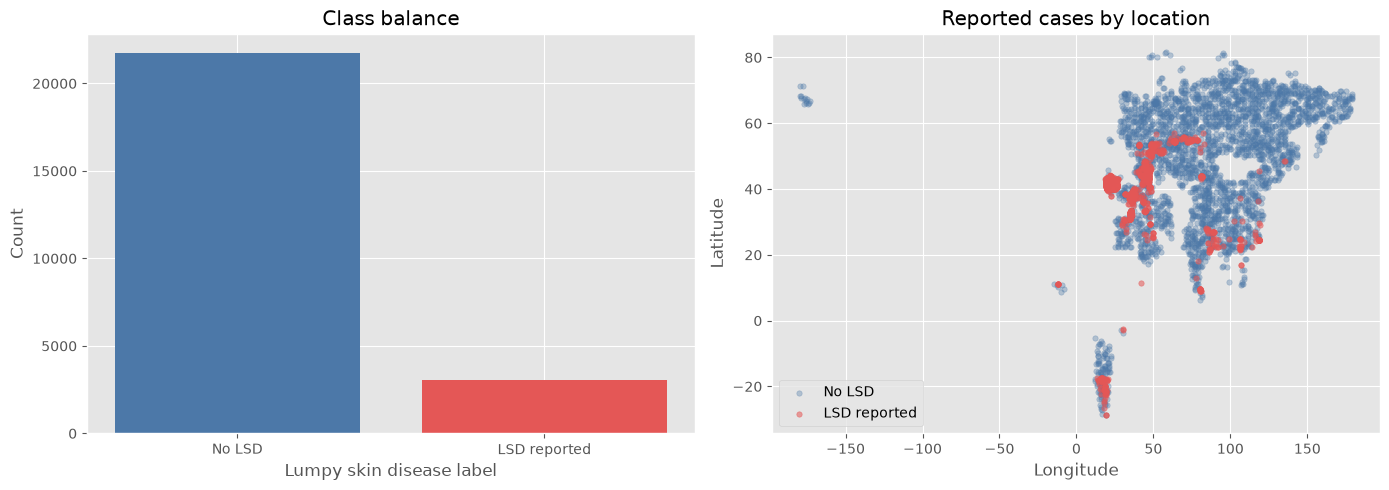

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['lumpy'].value_counts().sort_index()
axes[0].bar(['No LSD', 'LSD reported'], counts.values, color=['#4c78a8', '#e45756'])
axes[0].set_title('Class balance')
axes[0].set_xlabel('Lumpy skin disease label')
axes[0].set_ylabel('Count')

negative_sample = df[df['lumpy'] == 0].sample(n=3000, random_state=RANDOM_STATE)
positive_rows = df[df['lumpy'] == 1]
# I sampled the large negative class here so the outbreak locations stay readable.
axes[1].scatter(negative_sample['x'], negative_sample['y'], alpha=0.35, s=15, color='#4c78a8', label='No LSD')
axes[1].scatter(positive_rows['x'], positive_rows['y'], alpha=0.55, s=15, color='#e45756', label='LSD reported')
axes[1].set_title('Reported cases by location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend()

plt.tight_layout()
plt.show()

## Modeling plan

I kept the original class imbalance because it reflects the dataset, but I evaluated models with positive-class F1 and balanced accuracy so a high score would actually mean something. Hyperparameter tuning happens only on the training split through stratified cross-validation.

In [7]:
X = clean_df.drop(columns='lumpy')
y = clean_df['lumpy']

categorical_features = ['dominant_land_cover']
numeric_features = [col for col in X.columns if col not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

model_spaces = {
    'KNN': {
        'pipeline': Pipeline([
            ('preprocess', scaled_preprocessor),
            ('model', KNeighborsClassifier()),
        ]),
        'params': {
            'model__n_neighbors': [5, 11, 21],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2],
        },
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('preprocess', tree_preprocessor),
            ('model', RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
                class_weight='balanced_subsample',
            )),
        ]),
        'params': {
            'model__n_estimators': [200],
            'model__max_depth': [None, 12],
            'model__min_samples_leaf': [1, 5],
        },
    },
    'Linear SVM': {
        'pipeline': Pipeline([
            ('preprocess', scaled_preprocessor),
            ('model', LinearSVC(
                random_state=RANDOM_STATE,
                class_weight='balanced',
                dual=False,
                max_iter=5000,
            )),
        ]),
        'params': {
            'model__C': [0.1, 1.0, 3.0],
        },
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Train rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')

Train rows: 19,842
Test rows: 4,961


In [8]:
results = []
best_models = {}
confusion_matrices = {}
classification_reports = {}

for model_name, config in model_spaces.items():
    search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        scoring='f1',
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)

    preds = search.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)

    best_models[model_name] = search.best_estimator_
    confusion_matrices[model_name] = confusion_matrix(y_test, preds)
    classification_reports[model_name] = pd.DataFrame(report).T
    results.append({
        'model': model_name,
        'best_params': search.best_params_,
        'cv_f1': search.best_score_,
        'test_precision': precision_score(y_test, preds),
        'test_recall': recall_score(y_test, preds),
        'test_f1': f1_score(y_test, preds),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values('test_f1', ascending=False).reset_index(drop=True)
results_df[['cv_f1', 'test_precision', 'test_recall', 'test_f1', 'test_balanced_accuracy']] = (
    results_df[['cv_f1', 'test_precision', 'test_recall', 'test_f1', 'test_balanced_accuracy']].round(4)
)

display(results_df)

,model,best_params,cv_f1,test_precision,test_recall,test_f1,test_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.8872,0.8440,0.9342,0.8868,0.9550
1,KNN,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",0.8681,0.8501,0.8766,0.8632,0.9275
2,Linear SVM,{'model__C': 3.0},0.6625,0.5171,0.8684,0.6483,0.8776


In [9]:
for model_name in results_df['model']:
    print()
    print(model_name)
    print('-' * len(model_name))
    display(classification_reports[model_name].round(4))


Random Forest
-------------


,precision,recall,f1-score,support
0,0.9907,0.9759,0.9832,4353.0000
1,0.8440,0.9342,0.8868,608.0000
accuracy,0.9708,0.9708,0.9708,0.9708
macro avg,0.9173,0.9550,0.9350,4961.0000
weighted avg,0.9727,0.9708,0.9714,4961.0000



KNN
---


,precision,recall,f1-score,support
0,0.9827,0.9784,0.9805,4353.0000
1,0.8501,0.8766,0.8632,608.0000
accuracy,0.9659,0.9659,0.9659,0.9659
macro avg,0.9164,0.9275,0.9219,4961.0000
weighted avg,0.9664,0.9659,0.9662,4961.0000



Linear SVM
----------


,precision,recall,f1-score,support
0,0.9797,0.8867,0.9309,4353.0000
1,0.5171,0.8684,0.6483,608.0000
accuracy,0.8845,0.8845,0.8845,0.8845
macro avg,0.7484,0.8776,0.7896,4961.0000
weighted avg,0.9230,0.8845,0.8963,4961.0000


Random Forest gave me the strongest balance in this run, landing near `0.89` test F1 and recovering most positive cases. KNN stayed competitive at about `0.86` test F1, while the linear SVM found many positives but paid for that with much lower precision.

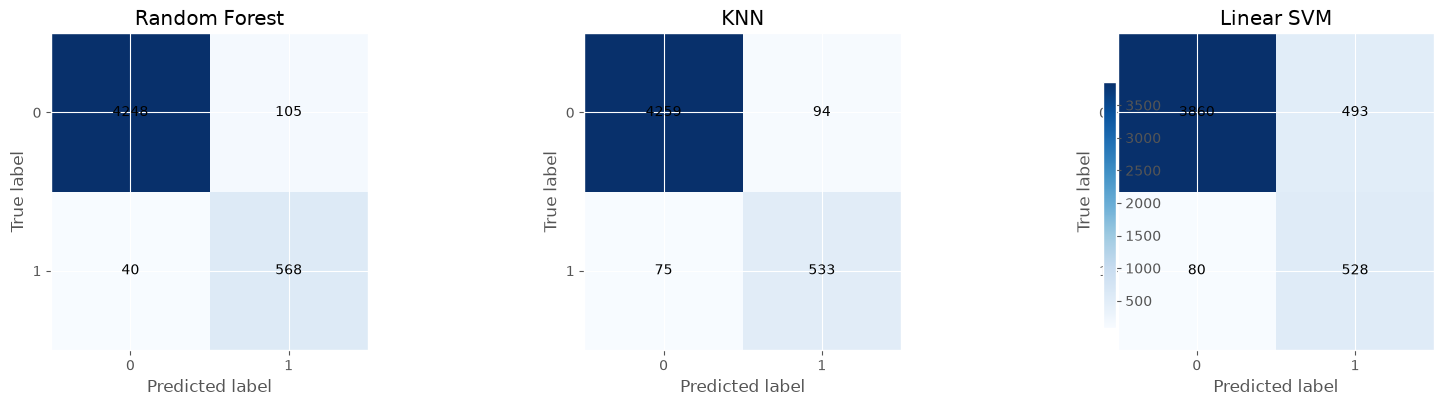

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, model_name in zip(axes, results_df['model']):
    cm = confusion_matrices[model_name]
    image = ax.imshow(cm, cmap='Blues')
    ax.set_title(model_name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1], ['0', '1'])
    ax.set_yticks([0, 1], ['0', '1'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(image, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

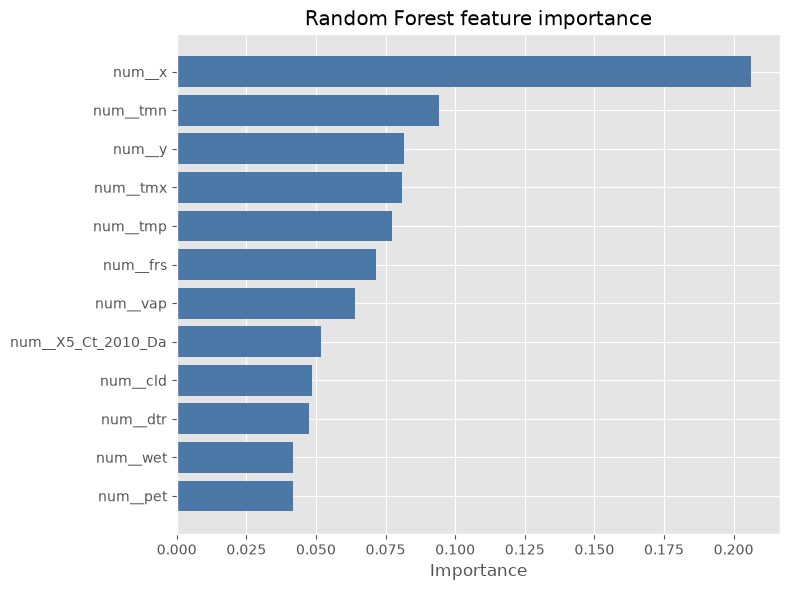

,importance
num__x,0.2063
num__tmn,0.0940
num__y,0.0817
num__tmx,0.0809
num__tmp,0.0775
num__frs,0.0714
num__vap,0.0641
num__X5_Ct_2010_Da,0.0520
num__cld,0.0487
num__dtr,0.0474


In [11]:
rf_model = best_models['Random Forest']
rf_feature_names = rf_model.named_steps['preprocess'].get_feature_names_out()
rf_importances = pd.Series(
    rf_model.named_steps['model'].feature_importances_,
    index=rf_feature_names,
).sort_values(ascending=False)

top_features = rf_importances.head(12).sort_values()
plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values, color='#4c78a8')
plt.title('Random Forest feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

display(rf_importances.head(12).round(4).to_frame(name='importance'))

## What I learned

The biggest lesson here was not about tuning a model. It was noticing that three metadata columns were almost direct shortcuts to the label because of how missing values were recorded.

After removing that leakage, the climate and geography features still carried useful signal. In my run, Random Forest handled that mix best, and the strongest numeric features were precipitation, longitude, and the temperature variables.